In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [6]:
data_path = "data"

## Evidence of resolution experiment

In [7]:
df = pd.read_csv(data_path+"/spatial_resolution_gemma_results_far.csv")

d0 = (df["D00_X"][0],df["D00_Y"][0])
d1 = (df["D01_X"][0],df["D01_Y"][0])
d2 = (df["D02_X"][0],df["D02_Y"][0])
d3 = (df["D03_X"][0],df["D03_Y"][0])

Text(0.5, 1.0, 'Prediction')

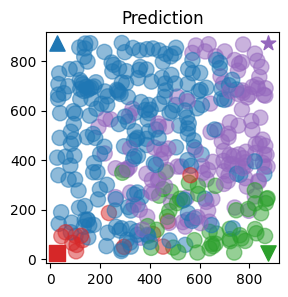

In [8]:
s = 120
shapes = ["square","triangle","heart","star"] 

f,axs = plt.subplots(1,1,figsize= (3,3))
axs.scatter(x=d0[0],y=d0[1],marker="s", s = s, color = "tab:red", zorder = 100)
axs.scatter(x=d1[0],y=d1[1],marker="^", s = s, color = "tab:blue", zorder = 100)
axs.scatter(x=d2[0],y=d2[1],marker="v", s = s, color = "tab:green", zorder = 100)
axs.scatter(x=d3[0],y=d3[1],marker="*", s = s, color = "tab:purple", zorder = 100)

cols = ["tab:red" if a == "square" else "tab:blue" if a == "triangle" else "tab:green" if a == "heart" else "tab:purple"  for a in df["answer"]]
axs.scatter(x=df["target_X"],y=df["target_Y"], color=cols, alpha = 0.5,s=120)
axs.set_title("Prediction")


In [9]:
df = pd.read_csv(data_path+"/spatial_resolution_qwen_results_far.csv")

d0 = (df["D00_X"][0],df["D00_Y"][0])
d1 = (df["D01_X"][0],df["D01_Y"][0])
d2 = (df["D02_X"][0],df["D02_Y"][0])
d3 = (df["D03_X"][0],df["D03_Y"][0])

Text(0.5, 1.0, 'Prediction')

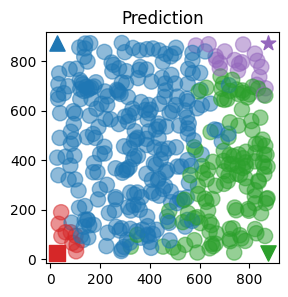

In [10]:
s = 120
shapes = ["square","triangle","heart","star"] 

f,axs = plt.subplots(1,1,figsize= (3,3))
axs.scatter(x=d0[0],y=d0[1],marker="s", s = s, color = "tab:red", zorder = 100)
axs.scatter(x=d1[0],y=d1[1],marker="^", s = s, color = "tab:blue", zorder = 100)
axs.scatter(x=d2[0],y=d2[1],marker="v", s = s, color = "tab:green", zorder = 100)
axs.scatter(x=d3[0],y=d3[1],marker="*", s = s, color = "tab:purple", zorder = 100)

cols = ["tab:red" if a == "square" else "tab:blue" if a == "triangle" else "tab:green" if a == "heart" else "tab:purple"  for a in df["answer"]]
axs.scatter(x=df["target_X"],y=df["target_Y"], color=cols, alpha = 0.5,s=120)
axs.set_title("Prediction")


Average over the randomized shapes

Text(0.5, 0.98, 'Prediction')

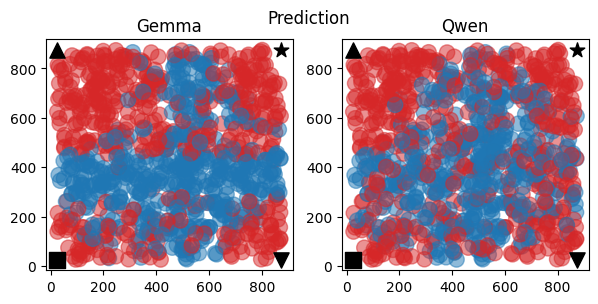

In [11]:
df = pd.read_csv(data_path+"/random_stencil_gemma_results.csv")

d0 = (df["D00_X"][0],df["D00_Y"][0])
d1 = (df["D01_X"][0],df["D01_Y"][0])
d2 = (df["D02_X"][0],df["D02_Y"][0])
d3 = (df["D03_X"][0],df["D03_Y"][0])
ds = [d0,d1,d2,d3]

s = 120
shapes = ["square","triangle","heart","star"] 

closest = np.argmin(np.array([np.sqrt((df["target_X"]-ds[i][0])**2+(df["target_Y"]-ds[i][1])**2).values for i in range(len(ds))]),0)
correct = np.array([df.iloc[i][f"D0{it}_SHAPE"] == df.iloc[i]["answer"] for i,it in enumerate(closest)])

f,axs = plt.subplots(1,2,figsize= (7,3))
axs[0].scatter(x=d0[0],y=d0[1],marker="s", s = s, color = "k", zorder = 100)
axs[0].scatter(x=d1[0],y=d1[1],marker="^", s = s, color = "k", zorder = 100)
axs[0].scatter(x=d2[0],y=d2[1],marker="v", s = s, color = "k", zorder = 100)
axs[0].scatter(x=d3[0],y=d3[1],marker="*", s = s, color = "k", zorder = 100)

cols = ["tab:red" if correct[i] == True else "tab:blue" for i in range(len(correct))]
axs[0].scatter(x=df["target_X"],y=df["target_Y"], color=cols, alpha = 0.5,s=120)
axs[0].set_title("Gemma")

df = pd.read_csv(data_path+"/random_stencil_qwen_results.csv")

d0 = (df["D00_X"][0],df["D00_Y"][0])
d1 = (df["D01_X"][0],df["D01_Y"][0])
d2 = (df["D02_X"][0],df["D02_Y"][0])
d3 = (df["D03_X"][0],df["D03_Y"][0])
ds = [d0,d1,d2,d3]

s = 120
shapes = ["square","triangle","heart","star"] 

closest = np.argmin(np.array([np.sqrt((df["target_X"]-ds[i][0])**2+(df["target_Y"]-ds[i][1])**2).values for i in range(len(ds))]),0)
correct = np.array([df.iloc[i][f"D0{it}_SHAPE"] == df.iloc[i]["answer"] for i,it in enumerate(closest)])


axs[1].scatter(x=d0[0],y=d0[1],marker="s", s = s, color = "k", zorder = 100)
axs[1].scatter(x=d1[0],y=d1[1],marker="^", s = s, color = "k", zorder = 100)
axs[1].scatter(x=d2[0],y=d2[1],marker="v", s = s, color = "k", zorder = 100)
axs[1].scatter(x=d3[0],y=d3[1],marker="*", s = s, color = "k", zorder = 100)

cols = ["tab:red" if correct[i] == True else "tab:blue" for i in range(len(correct))]
axs[1].scatter(x=df["target_X"],y=df["target_Y"], color=cols, alpha = 0.5,s=120)
axs[1].set_title("Qwen")
plt.suptitle("Prediction")


### Figure 5c

<Axes: >

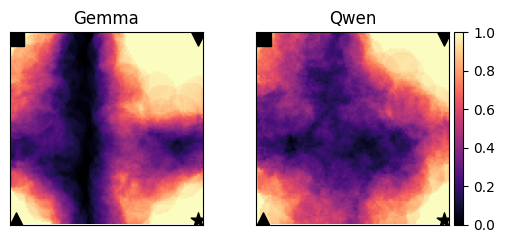

In [12]:
M = np.max(np.array(ds))
m = np.min(np.array(ds))

space = np.linspace(m,M,100)
eps = 90

f,axs = plt.subplots(1,2,figsize= (6,2.5))

df = pd.read_csv(data_path+"/random_stencil_gemma_results.csv")
grid_gemma = np.zeros((len(space),len(space)))
d0 = (df["D00_X"][0],df["D00_Y"][0])
d1 = (df["D01_X"][0],df["D01_Y"][0])
d2 = (df["D02_X"][0],df["D02_Y"][0])
d3 = (df["D03_X"][0],df["D03_Y"][0])
dsp = np.array([d0,d1,d2,d3])
ds = [d0,d1,d2,d3]
mx = 0
Mx = 900
my = 0
My = 900
dsp[:,0] = (dsp[:,0] - mx)/(Mx - mx)*len(space)
dsp[:,1] = (dsp[:,1] - my)/(My - my)*len(space)

axs[0].scatter(x=dsp[0,0],y=dsp[0,1],marker="s", s = s, color = "k", zorder = 100)
axs[0].scatter(x=dsp[1,0],y=dsp[1,1],marker="^", s = s, color = "k", zorder = 100)
axs[0].scatter(x=dsp[2,0],y=dsp[2,1],marker="v", s = s, color = "k", zorder = 100)
axs[0].scatter(x=dsp[3,0],y=dsp[3,1],marker="*", s = s, color = "k", zorder = 100)

targetX = df["target_X"].values
targetY = df["target_Y"].values
closest = np.argmin(np.array([np.sqrt((df["target_X"]-ds[i][0])**2+(df["target_Y"]-ds[i][1])**2).values for i in range(len(ds))]),0)
correct = np.array([df.iloc[i][f"D0{it}_SHAPE"] == df.iloc[i]["answer"] for i,it in enumerate(closest)])
for i in range(len(space)):
    for j in range(len(space)):
        which = np.sqrt((targetX - space[i])**2 + (targetY - space[j])**2 ) < eps
        grid_gemma[i,j] = np.mean(correct[which])
    
axs[0].imshow(grid_gemma,cmap = "magma")
axs[0].set_title("Gemma")
axs[0].set_xticks([])
axs[0].set_yticks([])


df = pd.read_csv(data_path+"/random_stencil_qwen_results.csv")
grid_qwen = np.zeros((len(space),len(space)))
d0 = (df["D00_X"][0],df["D00_Y"][0])
d1 = (df["D01_X"][0],df["D01_Y"][0])
d2 = (df["D02_X"][0],df["D02_Y"][0])
d3 = (df["D03_X"][0],df["D03_Y"][0])
ds = [d0,d1,d2,d3]
targetX = df["target_X"].values
targetY = df["target_Y"].values
closest = np.argmin(np.array([np.sqrt((df["target_X"]-ds[i][0])**2+(df["target_Y"]-ds[i][1])**2).values for i in range(len(ds))]),0)
correct = np.array([df.iloc[i][f"D0{it}_SHAPE"] == df.iloc[i]["answer"] for i,it in enumerate(closest)])
for i in range(len(space)):
    for j in range(len(space)):
        which = np.sqrt((targetX - space[i])**2 + (targetY - space[j])**2 ) < eps
        grid_qwen[i,j] = np.mean(correct[which])
    

axs[1].scatter(x=dsp[0,0],y=dsp[0,1],marker="s", s = s, color = "k", zorder = 100)
axs[1].scatter(x=dsp[1,0],y=dsp[1,1],marker="^", s = s, color = "k", zorder = 100)
axs[1].scatter(x=dsp[2,0],y=dsp[2,1],marker="v", s = s, color = "k", zorder = 100)
axs[1].scatter(x=dsp[3,0],y=dsp[3,1],marker="*", s = s, color = "k", zorder = 100)


axs[1].imshow(grid_qwen,cmap = "magma")
axs[1].set_title("Qwen")
axs[1].set_xticks([])
axs[1].set_yticks([])

divider = make_axes_locatable(plt.gca())
ax_cb = divider.new_horizontal(size="5%", pad=0.05)    
cb1 = mpl.colorbar.ColorbarBase(ax_cb, cmap=mpl.cm.magma, orientation='vertical')

plt.gcf().add_axes(ax_cb)

## Color similarity test

In [14]:
df_id_gemma = pd.read_csv(data_path+"/color_identification_gemma_results.csv")
df_id_qwen = pd.read_csv(data_path+"/color_identification_qwen_results.csv")

df_sim_gemma = pd.read_csv(data_path+"/color_similarity_gemma_results.csv")
df_sim_qwen = pd.read_csv(data_path+"/color_similarity_qwen_results.csv")

In [15]:
n_stencils = [4,6,8,10,12]
performances_gemma_id = []
performances_qwen_id = []

performances_gemma_sim = []
performances_qwen_sim = []

letters = ["A","B","C","D","E","F","G","H","I","J","K","L","M","N"]
for n in n_stencils:
    df_n = df_id_gemma.loc[df_id_gemma["N_STENCILS"] == n]
    corrects = []
    for i in range(len(df_n)):
        corrects.append(letters[np.argmax([df_n.iloc[i][f"HUE_{L}_sim"] for L in letters[:n]])])
    corrects = np.array(corrects)
    performance = np.mean(corrects == df_n["answer"].values)
    performances_gemma_id.append(performance)
for n in n_stencils:
    df_n = df_id_qwen.loc[df_id_qwen["N_STENCILS"] == n]
    corrects = []
    for i in range(len(df_n)):
        corrects.append(letters[np.argmax([df_n.iloc[i][f"HUE_{L}_sim"] for L in letters[:n]])])
    corrects = np.array(corrects)
    performance = np.mean(corrects == df_n["answer"].values)
    performances_qwen_id.append(performance)

for n in n_stencils:
    df_n = df_sim_gemma.loc[df_sim_gemma["N_STENCILS"] == n]
    corrects = []
    for i in range(len(df_n)):
        corrects.append(letters[np.argmax([df_n.iloc[i][f"HUE_{L}_sim"] for L in letters[:n]])])
    corrects = np.array(corrects)
    performance = np.mean(corrects == df_n["answer"].values)
    performances_gemma_sim.append(performance)
for n in n_stencils:
    df_n = df_sim_qwen.loc[df_sim_qwen["N_STENCILS"] == n]
    corrects = []
    for i in range(len(df_n)):
        corrects.append(letters[np.argmax([df_n.iloc[i][f"HUE_{L}_sim"] for L in letters[:n]])])
    corrects = np.array(corrects)
    performance = np.mean(corrects == df_n["answer"].values)

    performances_qwen_sim.append(performance)

Fit the identification curves

In [16]:
from scipy.optimize import curve_fit
import numpy as np

# Define the model function
def model_func(n, a):
    n = np.array(n)
    return (1 - (1 - a) ** n) / (a * n)

# Prepare data
xdata = np.array(n_stencils)

# Fit the model
popt, pcov = curve_fit(model_func, xdata, np.array(performances_gemma_id), p0=[0.1])
a_fit = popt[0]

popt, pcov = curve_fit(model_func, xdata, np.array(performances_qwen_id), p0=[0.1])
a_fit_qwen = popt[0]

### Figure 14a

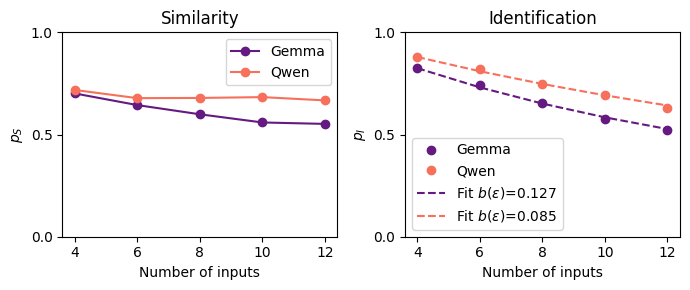

In [18]:
f,axs = plt.subplots(1,2,figsize=(7,3))
axs[0].plot(n_stencils,performances_gemma_sim,'-o', color = plt.cm.magma(0.3), label = "Gemma")
axs[0].plot(n_stencils,performances_qwen_sim,'-o', color = plt.cm.magma(0.7), label = "Qwen")
axs[0].legend()
axs[0].set_ylim([0,1])
axs[0].set_title("Similarity")
axs[0].set_ylabel("$p_S$")
axs[0].set_xlabel("Number of inputs")
axs[0].set_yticks([0,0.5,1])

axs[1].plot(n_stencils,performances_gemma_id,'o',  color = plt.cm.magma(0.3),label = "Gemma")
axs[1].plot(n_stencils,performances_qwen_id,'o', color = plt.cm.magma(0.7), label = "Qwen")
axs[1].plot(n_stencils, model_func(n_stencils, a_fit), '--', color = plt.cm.magma(0.3), label=f'Fit '+r'$b(\varepsilon)$'+f'={a_fit:.3f}')
axs[1].plot(n_stencils, model_func(n_stencils, a_fit_qwen), '--', color = plt.cm.magma(0.7), label=f'Fit '+r'$b(\varepsilon)$'+f'={a_fit_qwen:.3f}')

axs[1].legend()
axs[1].set_ylim([0,1])
axs[1].set_title("Identification")
axs[1].set_ylabel("$p_I$")
axs[1].set_xlabel("Number of inputs")
axs[1].set_yticks([0,0.5,1])
plt.tight_layout()


In [ ]:
score_gemma_sim = []
dists_gemma_sim = []
corrects_gemma = []
correct_dist_gemma = []
correct_score_gemma = []
for n in n_stencils:
    df_n = df_sim_gemma.loc[df_sim_gemma["N_STENCILS"] == n]
    corrects = []
    for i in range(len(df_n)):
        corrects_gemma.append(letters[np.argmax([df_n.iloc[i][f"HUE_{L}_sim"] for L in letters[:n]])])
        correct_dist_gemma.append(df_n.iloc[i][f"HUE_{corrects_gemma[-1]}_sim"])
        correct_score_gemma.append(df_n.iloc[i][f"{corrects_gemma[-1]}"])
        for l in letters[:n]: # The input is not the correct answer
            if l != corrects_gemma[-1]:
                dists_gemma_sim.append(df_n.iloc[i][f"HUE_{l}_sim"])
                score_gemma_sim.append(df_n.iloc[i][f"{l}"])
dists_gemma_sim = np.array(dists_gemma_sim)

score_qwen_sim = []
dists_qwen_sim = []
corrects_qwen = []
correct_dist_qwen = []
correct_score_qwen = []
for n in n_stencils:
    df_n = df_sim_qwen.loc[df_sim_qwen["N_STENCILS"] == n]
    corrects = []
    for i in range(len(df_n)):
        corrects_qwen.append(letters[np.argmax([df_n.iloc[i][f"HUE_{L}_sim"] for L in letters[:n]])])
        correct_dist_qwen.append(df_n.iloc[i][f"HUE_{corrects_qwen[-1]}_sim"])
        correct_score_qwen.append(df_n.iloc[i][f"{corrects_qwen[-1]}"])
        for l in letters[:n]:
            if l != corrects_qwen[-1]: # The input is not the correct answer
                dists_qwen_sim.append(df_n.iloc[i][f"HUE_{l}_sim"])
                score_qwen_sim.append(df_n.iloc[i][f"{l}"])
dists_qwen_sim = np.array(dists_qwen_sim)

### Figure 14b

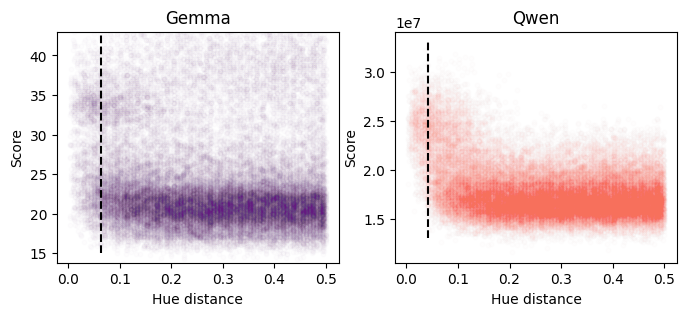

In [21]:
f,axs = plt.subplots(1,2,figsize=(8,3))
s = 10
axs[0].scatter((1-dists_gemma_sim)*0.5,score_gemma_sim,alpha=0.01,s = s, color = plt.cm.magma(0.3))
axs[0].set_xlabel("Hue distance")
axs[0].set_ylabel("Score")
axs[0].set_title("Gemma")
axs[0].set_ylim(np.min(score_gemma_sim),43)
axs[0].vlines(a_fit/2,15,43,color ="k",linestyle = "--")
axs[1].scatter((1-np.array(dists_qwen_sim))*0.5,score_qwen_sim,alpha=0.01, s = s,color = plt.cm.magma(0.7))
axs[1].set_xlabel("Hue distance")
axs[1].set_ylabel("Score")
axs[1].set_title("Qwen")
axs[1].vlines(a_fit_qwen/2,1.3*1e7,3.3*1e7,color ="k",linestyle = "--")
